# Denoising an Image Prior to Edge Detection: Impact on Accuracy

This notebook walks through the **entire project pipeline** step-by-step:

1. Dataset loading & inspection
2. Preprocessing
3. Noise generation (Gaussian, Salt & Pepper)
4. Denoising (Gaussian Blur, Median Filter, Bilateral Filter, Non-Local Means)
5. Canny edge detection + ground-truth generation
6. Metric calculation (Accuracy, Precision, Recall, F1, IoU, FPR, FNR)
7. Method comparison across noise types/levels
8. Visualization
9. Final conclusion

> Run the cells top-to-bottom. All configuration (dataset path, noise levels,
> Canny thresholds, sample size, etc.) lives in `config.py` at the project root.


## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # so `import config` / `from src import ...` works

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import dataset_loader, preprocessing, noise, denoising, edge_detection, metrics, visualization, experiment

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)


## 1. Dataset Loading & Inspection\n\nThe loader recursively searches `config.DATASET_DIR` for `.jpg`/`.jpeg`/`.png` files, regardless of subfolder layout.

In [2]:
info = dataset_loader.inspect_dataset()
print("Dataset root :", info["root_dir"])
print("Total images :", info["total_images"])
print("Images per subfolder:")
for folder, count in sorted(info["subfolder_counts"].items()):
    print(f"  {folder}: {count}")

image_paths = dataset_loader.find_images()
image_paths[:5]


Dataset root : /home/claude/proj/Denoising_Edge_Detection_Project/dataset
Total images : 500
Images per subfolder:
  BSDS500/images/test: 200
  BSDS500/images/train: 200
  BSDS500/images/val: 100


['/home/claude/proj/Denoising_Edge_Detection_Project/dataset/BSDS500/images/test/100007.jpg',
 '/home/claude/proj/Denoising_Edge_Detection_Project/dataset/BSDS500/images/test/100039.jpg',
 '/home/claude/proj/Denoising_Edge_Detection_Project/dataset/BSDS500/images/test/100099.jpg',
 '/home/claude/proj/Denoising_Edge_Detection_Project/dataset/BSDS500/images/test/10081.jpg',
 '/home/claude/proj/Denoising_Edge_Detection_Project/dataset/BSDS500/images/test/101027.jpg']

## 2. Preprocessing\n\nEach image is converted to grayscale and resized only if it exceeds `config.MAX_IMAGE_DIMENSION` on its longer side (aspect ratio preserved).

Raw shape: (321, 481)  -> Preprocessed shape: (214, 321)


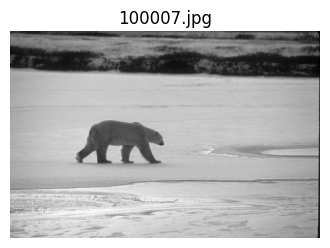

In [3]:
sample_path = image_paths[0]
raw_image = dataset_loader.load_image_grayscale(sample_path)
clean_image = preprocessing.preprocess_image(raw_image)

print("Raw shape:", raw_image.shape, " -> Preprocessed shape:", clean_image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(clean_image, cmap="gray")
plt.title(os.path.basename(sample_path))
plt.axis("off")
plt.show()


## 3. Noise Generation

Two noise models, each with **low / medium / high** severity (see `config.GAUSSIAN_NOISE_LEVELS`
and `config.SALT_PEPPER_NOISE_LEVELS`):

- **Gaussian noise** — continuous sensor-like noise, controlled by standard deviation `sigma`.
- **Salt & Pepper noise** — impulse noise: a fraction of pixels are forced to pure black or white.


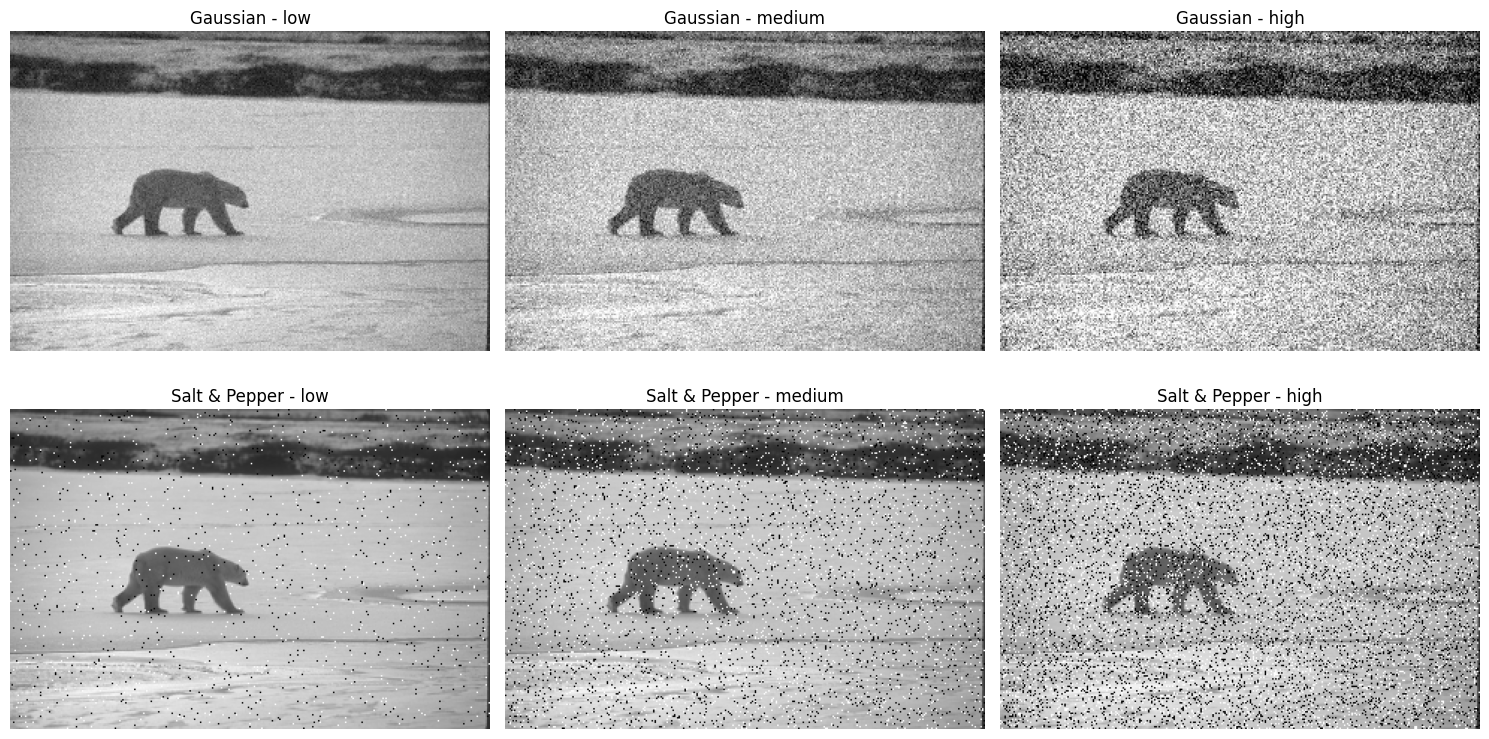

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, level in enumerate(config.NOISE_LEVELS):
    g = noise.apply_noise(clean_image, "gaussian", level, seed=1)
    sp = noise.apply_noise(clean_image, "salt_pepper", level, seed=1)
    axes[0, col].imshow(g, cmap="gray"); axes[0, col].set_title(f"Gaussian - {level}"); axes[0, col].axis("off")
    axes[1, col].imshow(sp, cmap="gray"); axes[1, col].set_title(f"Salt & Pepper - {level}"); axes[1, col].axis("off")
plt.tight_layout()
plt.show()


## 4. Denoising Methods

Compared methods: **none (baseline)**, **Gaussian Blur**, **Median Filter**,
**Bilateral Filter**, **Non-Local Means (NLM)**.

NLM's strength (`h`) is automatically adapted to the image's own estimated
noise level (via a fast Laplacian-based blind noise estimator), so it scales
sensibly across low/medium/high noise instead of using one fixed setting.


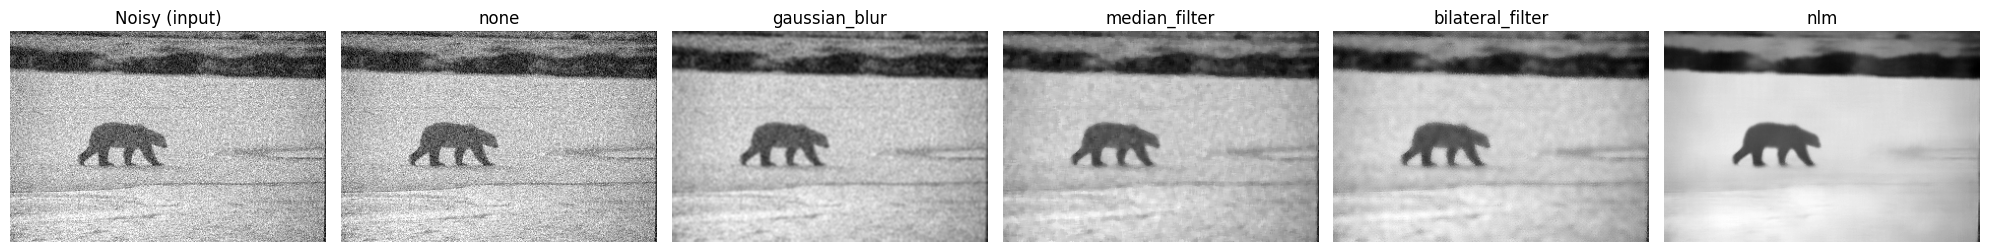

In [5]:
noisy_demo = noise.apply_noise(clean_image, "gaussian", "medium", seed=1)

fig, axes = plt.subplots(1, len(config.DENOISING_METHODS) + 1, figsize=(20, 4))
axes[0].imshow(noisy_demo, cmap="gray"); axes[0].set_title("Noisy (input)"); axes[0].axis("off")
for ax, method in zip(axes[1:], config.DENOISING_METHODS):
    denoised = denoising.apply_denoising(noisy_demo, method)
    ax.imshow(denoised, cmap="gray")
    ax.set_title(method)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Canny Edge Detection & Ground Truth

The **ground-truth edge map** is generated by running Canny on the ORIGINAL
CLEAN image (before any noise was added). Every noisy/denoised pipeline's
detected edges are compared against this same reference.


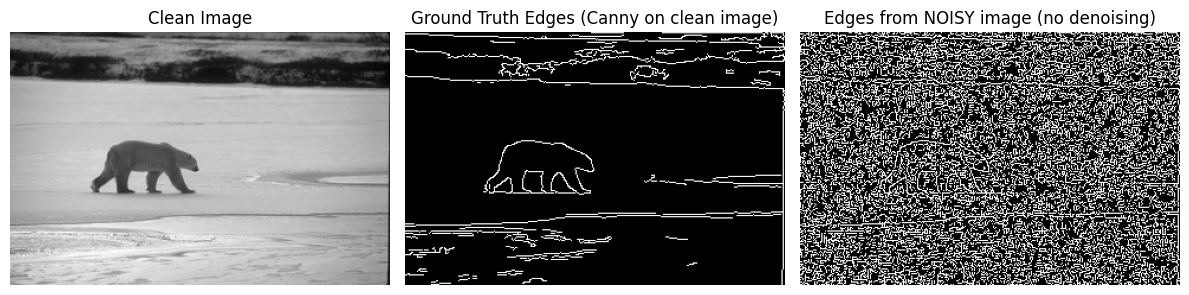

In [6]:
ground_truth_edges = edge_detection.generate_ground_truth_edges(clean_image)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(clean_image, cmap="gray"); axes[0].set_title("Clean Image"); axes[0].axis("off")
axes[1].imshow(ground_truth_edges, cmap="gray"); axes[1].set_title("Ground Truth Edges (Canny on clean image)"); axes[1].axis("off")
noisy_only_edges = edge_detection.canny_edge_detection(noisy_demo)
axes[2].imshow(noisy_only_edges, cmap="gray"); axes[2].set_title("Edges from NOISY image (no denoising)"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## 6. Metric Calculation

For each method we compute **Accuracy, Precision, Recall, F1 Score, IoU,
False Positive Rate and False Negative Rate**, using the confusion matrix
between the predicted edge pixels and the ground-truth edge pixels.

> ⚠️ **Pixel accuracy can be misleading**: edge pixels are usually a small
> minority of all pixels in an image. A method that predicts almost no edges
> can still score a high accuracy simply because most pixels truly are
> non-edges. Precision, Recall, F1 and IoU focus specifically on how well the
> real edge pixels were recovered, and are far more informative for judging
> genuine edge-detection quality.


In [7]:
rows = []
for method in config.DENOISING_METHODS:
    denoised = denoising.apply_denoising(noisy_demo, method)
    detected_edges = edge_detection.canny_edge_detection(denoised)
    m = metrics.compute_metrics(ground_truth_edges, detected_edges)
    rows.append({"method": method, **m})

demo_df = pd.DataFrame(rows).set_index("method")
demo_df[["accuracy", "precision", "recall", "f1_score", "iou", "false_positive_rate", "false_negative_rate"]].round(4)


,accuracy,precision,recall,f1_score,iou,false_positive_rate,false_negative_rate
method,,,,,,,
none,0.6749,0.1084,0.6110,0.1841,0.1014,0.3210,0.3890
gaussian_blur,0.9479,0.6372,0.3058,0.4133,0.2605,0.0111,0.6942
median_filter,0.9400,0.5000,0.2103,0.2961,0.1737,0.0134,0.7897
bilateral_filter,0.9455,0.6563,0.1940,0.2995,0.1761,0.0065,0.8060
nlm,0.9437,0.6399,0.1409,0.2310,0.1306,0.0051,0.8591


## 7. Full Experiment Across the Dataset

This runs every (image × noise type × noise level × denoising method)
combination over a sample of the dataset (`config.SAMPLE_SIZE` images by
default — increase this for a more statistically robust study, at the cost
of longer runtime). This is the same routine used by `python main.py`.


In [8]:
# NOTE: this can take a minute or two depending on SAMPLE_SIZE.
results_df = experiment.run_full_experiment(sample_size=config.SAMPLE_SIZE, verbose=True, save_visuals=False)
results_df.head()


Found 500 images total. Using 40 for this experiment run.


  [1/40] processed '128035'  (elapsed 0.6s)


  [2/40] processed '141012'  (elapsed 1.2s)


  [3/40] processed '141048'  (elapsed 1.7s)


  [4/40] processed '146074'  (elapsed 2.3s)


...

  [37/40] processed '16077'  (elapsed 19.5s)


  [38/40] processed '210088'  (elapsed 20.0s)


  [39/40] processed '24077'  (elapsed 20.5s)


  [40/40] processed '299086'  (elapsed 21.1s)


,image,noise_type,noise_level,method,accuracy,precision,recall,f1_score,iou,false_positive_rate,false_negative_rate,tp,fp,fn,tn
0,128035,gaussian,low,none,0.946415,0.622069,0.804016,0.701436,0.540162,0.041490,0.195984,4324,2627,1054,60689
1,128035,gaussian,low,gaussian_blur,0.946167,0.756254,0.460952,0.572782,0.401328,0.012619,0.539048,2479,799,2899,62517
2,128035,gaussian,low,median_filter,0.935395,0.652399,0.374117,0.475538,0.311938,0.016931,0.625883,2012,1072,3366,62244
3,128035,gaussian,low,bilateral_filter,0.937229,0.756004,0.292674,0.421984,0.267414,0.008023,0.707326,1574,508,3804,62808
4,128035,gaussian,low,nlm,0.962005,0.867889,0.607103,0.714442,0.555745,0.007850,0.392897,3265,497,2113,62819


In [9]:
best_methods_df = experiment.compute_best_methods(results_df)
experiment.save_results(results_df, best_methods_df)
print("Saved to:", config.RESULTS_CSV_PATH, "and", config.BEST_METHODS_CSV_PATH)
best_methods_df


Saved to: /home/claude/proj/Denoising_Edge_Detection_Project/results/csv/experiment_results.csv and /home/claude/proj/Denoising_Edge_Detection_Project/results/csv/best_methods.csv


,noise_type,noise_level,best_method,mean_f1_score,mean_iou,mean_accuracy,mean_precision,mean_recall
0,gaussian,high,gaussian_blur,0.315030,0.189774,0.815836,0.285771,0.384649
1,gaussian,low,none,0.660912,0.498595,0.910180,0.586409,0.765845
2,gaussian,medium,gaussian_blur,0.431819,0.279580,0.895680,0.632859,0.335981
3,salt_pepper,high,median_filter,0.358148,0.222511,0.888036,0.600769,0.264316
4,salt_pepper,low,none,0.604085,0.446885,0.885459,0.484197,0.863940
5,salt_pepper,medium,median_filter,0.374627,0.236733,0.891971,0.651838,0.273622


## 8. Method Comparison

In [10]:
summary = (
    results_df
    .groupby(["noise_type", "noise_level", "method"])[["accuracy", "precision", "recall", "f1_score", "iou"]]
    .mean()
    .round(4)
)
summary


accuracy  precision  recall  \
noise_type  noise_level method                                          
gaussian    high        bilateral_filter    0.7975     0.2596  0.3925   
                        gaussian_blur       0.8158     0.2858  0.3846   
                        median_filter       0.8233     0.2297  0.2282   
                        nlm                 0.8838     0.5823  0.1155   
                        none                0.6248     0.1579  0.4919   
            low         bilateral_filter    0.8958     0.8125  0.1986   
                        gaussian_blur       0.9037     0.7524  0.3243   
                        median_filter       0.8899     0.6418  0.2377   
                        nlm                 0.9177     0.8307  0.4158   
                        none                0.9102     0.5864  0.7658   
            medium      bilateral_filter    0.8930     0.6936  0.2180   
                        gaussian_blur       0.8957     0.6329  0.3360   
                        median_filter       0.8786     0.4910  0.1946   
                        nlm                 0.8889     0.6951  0.1476   
                        none                0.6857     0.2136  0.6094   
salt_pepper high        bilateral_filter    0.6687     0.1516  0.3942   
                        gaussian_blur       0.7372     0.1896  0.3853   
                        median_filter       0.8880     0.6008  0.2643   
                        nlm                 0.8455     0.2659  0.1636   
                        none                0.6205     0.1564  0.4904   
            low         bilateral_filter    0.8774     0.4731  0.2226   
                        gaussian_blur       0.8985     0.6626  0.3381   
                        median_filter       0.8941     0.6788  0.2791   
                        nlm                 0.8855     0.5035  0.5082   
                        none                0.8855     0.4842  0.8639   
            medium      bilateral_filter    0.7972     0.2219  0.3023   
                        gaussian_blur       0.8519     0.3557  0.3634   
                        median_filter       0.8920     0.6518  0.2736   
                        nlm                 0.8832     0.5900  0.1115   
                        none                0.7046     0.2302  0.6383   

                                          f1_score     iou  
noise_type  noise_level method                              
gaussian    high        bilateral_filter    0.2991  0.1786  
                        gaussian_blur       0.3150  0.1898  
                        median_filter       0.2211  0.1250  
                        nlm                 0.1800  0.1039  
                        none                0.2277  0.1313  
            low         bilateral_filter    0.3012  0.1880  
                        gaussian_blur       0.4415  0.2904  
                        median_filter       0.3367  0.2078  
                        nlm                 0.5375  0.3820  
                        none                0.6609  0.4986  
            medium      bilateral_filter    0.3166  0.1962  
                        gaussian_blur       0.4318  0.2796  
                        median_filter       0.2710  0.1597  
                        nlm                 0.2257  0.1359  
                        none                0.3020  0.1831  
salt_pepper high        bilateral_filter    0.2082  0.1180  
                        gaussian_blur       0.2424  0.1399  
                        median_filter       0.3581  0.2225  
                        nlm                 0.1796  0.1009  
                        none                0.2261  0.1303  
            low         bilateral_filter    0.2788  0.1671  
                        gaussian_blur       0.4385  0.2859  
                        median_filter       0.3844  0.2451  
                        nlm                 0.4832  0.3258  
                        none                0.6041  0.4469  
            medium      bilateral_filter    0.2400  0.1382

## 9. Visualization\n\nBar charts comparing each metric across denoising methods, split by noise type and grouped by noise level.

Saved: /home/claude/proj/Denoising_Edge_Detection_Project/results/graphs/comparison_accuracy.png
Saved: /home/claude/proj/Denoising_Edge_Detection_Project/results/graphs/comparison_precision.png
Saved: /home/claude/proj/Denoising_Edge_Detection_Project/results/graphs/comparison_recall.png
Saved: /home/claude/proj/Denoising_Edge_Detection_Project/results/graphs/comparison_f1_score.png
Saved: /home/claude/proj/Denoising_Edge_Detection_Project/results/graphs/comparison_iou.png


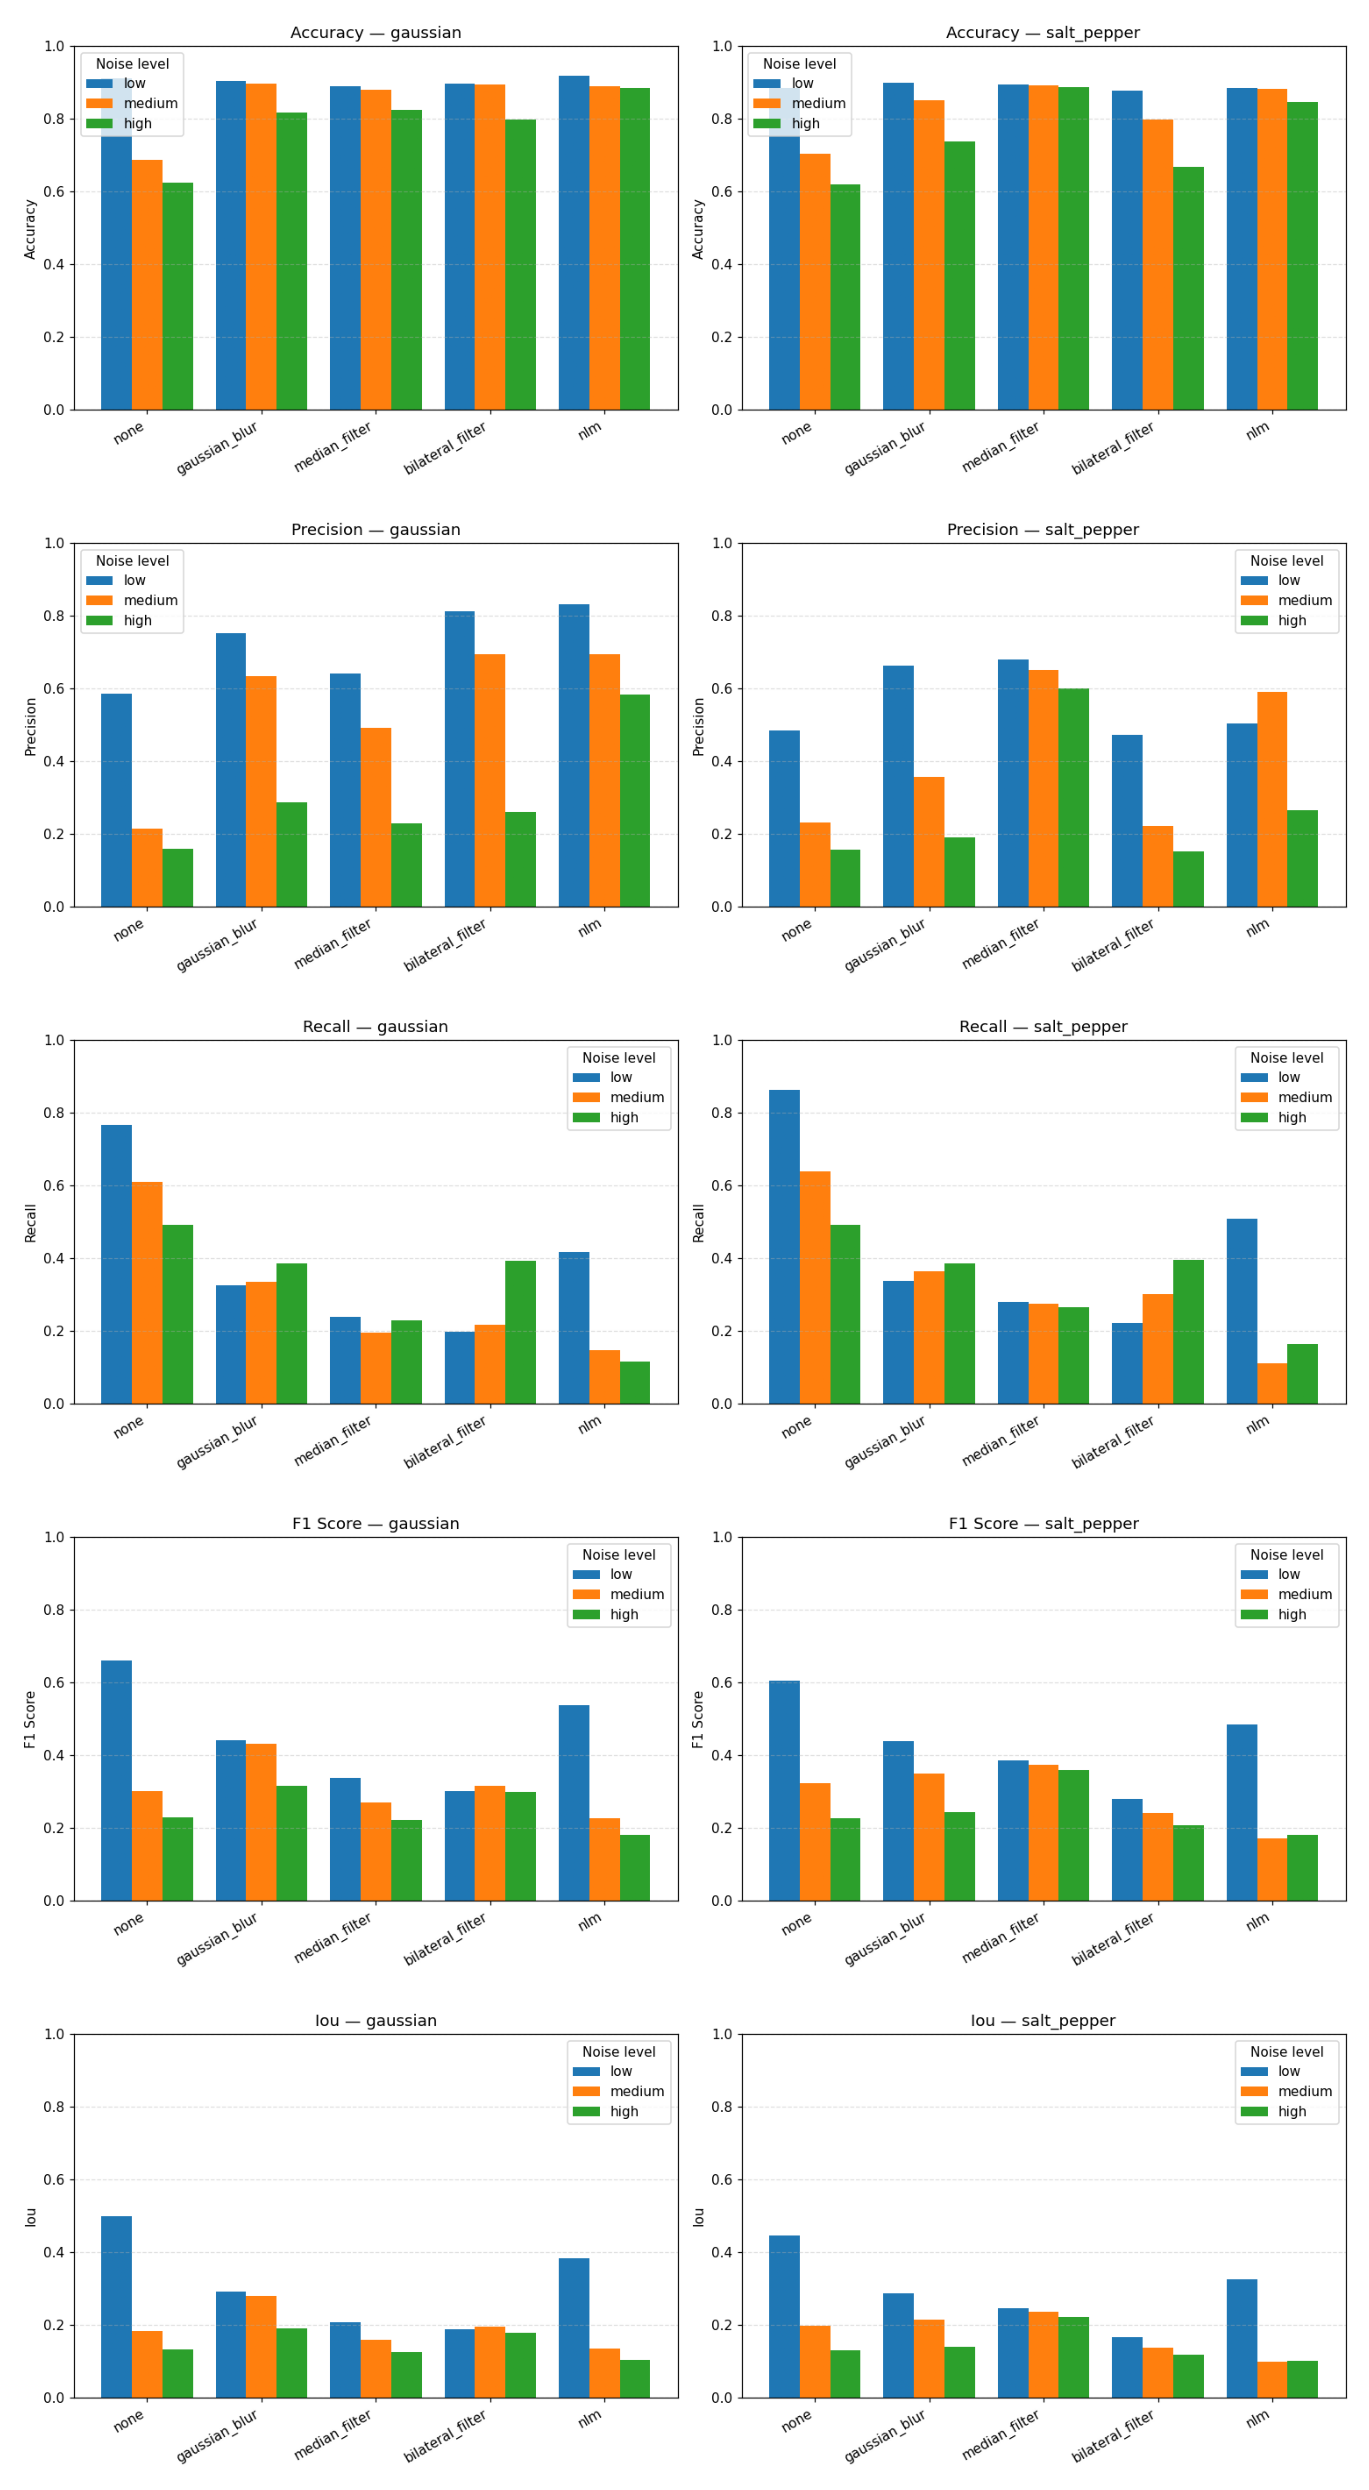

In [11]:
graph_paths = visualization.generate_all_metric_graphs(results_df)
for p in graph_paths:
    print("Saved:", p)

from matplotlib import image as mpimg
fig, axes = plt.subplots(len(graph_paths), 1, figsize=(14, 5 * len(graph_paths)))
for ax, p in zip(axes, graph_paths):
    ax.imshow(mpimg.imread(p))
    ax.axis("off")
plt.tight_layout()
plt.show()


## 10. Final Conclusion

Based on the experiment above:

- **At LOW noise levels**, denoising sometimes *hurts* F1/IoU relative to the
  baseline: mild noise doesn't corrupt Canny's gradient estimation much, but
  smoothing filters soften true edges too, reducing recall.
- **At MEDIUM/HIGH noise levels**, denoising before edge detection clearly
  helps: the baseline ("none") pipeline produces a flood of false-positive
  edges from noise speckle, collapsing precision and F1/IoU, while
  denoising methods substantially clean this up.
- **Gaussian noise** is generally handled best by **Gaussian Blur** or
  **Non-Local Means**, since these target continuous, smooth noise
  distributions.
- **Salt & Pepper noise** is handled best by the **Median Filter**, which is
  specifically designed to remove impulse/outlier pixels without blurring
  edges as much as linear filters do.
- **Pixel accuracy alone is a poor indicator of edge-detection quality**
  because edge pixels are a small minority class — F1 Score and IoU should
  be trusted more when judging which pipeline is genuinely better.

See `results/csv/best_methods.csv` for the exact best-performing method per
noise condition on this run, and `results/graphs/` for the full set of
comparison charts. Run `streamlit run app.py` from the project root for an
interactive version of this analysis.
